# Decimation/Interpolation Filter design

Design a lowpass FIR filter for 10:1 decimation (200 kHz → 20 kHz) and 10:1 interpolation (20 kHz → 200 kHz), and generate Rust source code with
Q31 coefficients ready to paste into src/dsp.rs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

The filter parameters (decimation/interpolation rate, sample rate and cutoff frequency) are

In [2]:

DECIMATE_FACTOR = 10        # decimation / interpolation factor
FS_IN           = 200_000   # input sample rate [Hz]
FC              = 5_000     # lowpass cutoff [Hz]

We can now design the filter.

In [3]:
# numtaps must be a multiple of DECIMATE_FACTOR for the polyphase decomposition
# used by both arm_fir_decimate_q31 and arm_fir_interpolate_q31.
NUMTAPS = 6 * DECIMATE_FACTOR  # 60

# Half-buffer size: number of input samples processed per DSP call.
# Must match FRAME_SAMPLES in src/config.rs.
BLOCK_SIZE = 100

# ---------------------------------------------------------------------------
# Filter design
# ---------------------------------------------------------------------------
fn   = FS_IN / 2                        # Nyquist frequency [Hz]
taps = sig.firwin(NUMTAPS, FC / fn,     # normalised cutoff
                  pass_zero='lowpass')


The frequency response of the filter is shown below.

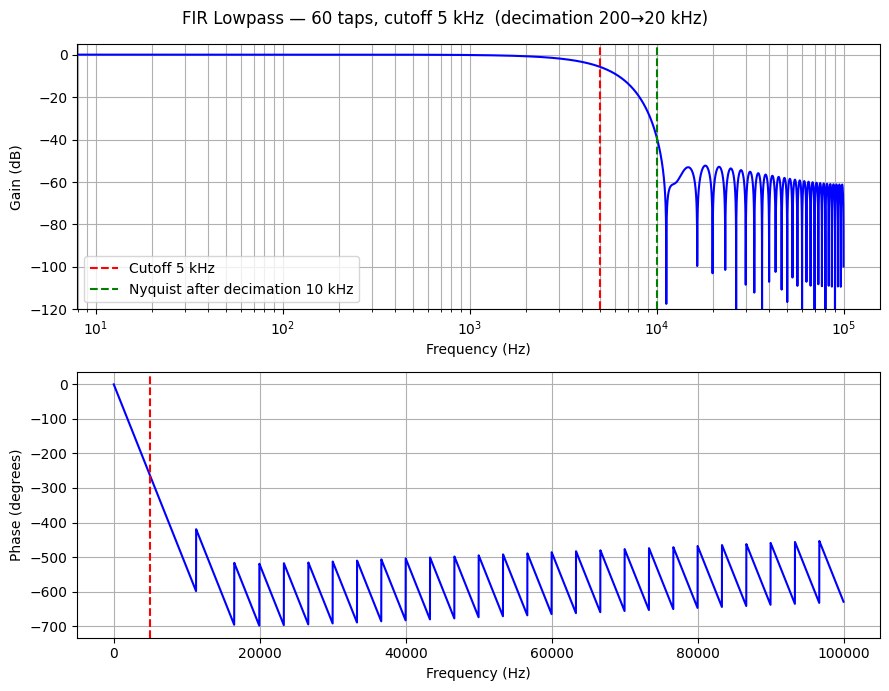

In [4]:

# ---------------------------------------------------------------------------
# Frequency response plot
# ---------------------------------------------------------------------------
w, h = sig.freqz(taps, worN=8000, fs=FS_IN)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
fig.suptitle(f'FIR Lowpass — {NUMTAPS} taps, cutoff {FC//1000} kHz  '
             f'(decimation {FS_IN//1000}→{FS_IN//DECIMATE_FACTOR//1000} kHz)')

ax1.semilogx(w, 20 * np.log10(np.abs(h) + 1e-12), 'b')
ax1.axvline(FC,                             color='r', ls='--', label=f'Cutoff {FC//1000} kHz')
ax1.axvline(FS_IN // (2 * DECIMATE_FACTOR), color='g', ls='--',
            label=f'Nyquist after decimation {FS_IN//(2*DECIMATE_FACTOR)//1000} kHz')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Gain (dB)')
ax1.set_ylim(-120, 5)
ax1.grid(True, which='both')
ax1.legend()

ax2.plot(w, np.unwrap(np.angle(h)) * 180 / np.pi, 'b')
ax2.axvline(FC, color='r', ls='--')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Phase (degrees)')
ax2.grid(True)

plt.tight_layout()
plt.show()


The filter is implemented in fixed point for compatibility with the CORDIC that is used right before upsampling and rust code is generated.

In [5]:
# Q31: signed 32-bit with implicit binary point after bit 30.
# Range [-1, 1);  scale factor = 2^31 - 1.
Q31_SCALE = (1 << 31) - 1
taps_q31  = np.round(taps * Q31_SCALE).astype(np.int32)

# FIR implementations expect time-reversed coefficients (oldest sample first).
taps_q31_rev = np.flip(taps_q31)

# State buffer length for the decimator / interpolator:
#   numTaps + blockSize - 1   (per CMSIS-DSP documentation)
STATE_LEN = NUMTAPS + BLOCK_SIZE - 1

# ---------------------------------------------------------------------------
# Rust source generation
# ---------------------------------------------------------------------------
coeffs_str = ',\n    '.join(f'{c:12d}' for c in taps_q31_rev)

rust_code = f"""\
// FIR lowpass filter for 10:1 decimation (200 kHz → 20 kHz) and
// 10:1 interpolation (20 kHz → 200 kHz).
//
//   Input rate  : {FS_IN // 1000} kHz
//   Output rate : {FS_IN // DECIMATE_FACTOR // 1000} kHz
//   Cutoff      : {FC // 1000} kHz
//   Stopband    : {FS_IN // DECIMATE_FACTOR // 1000} kHz (Nyquist after decimation)
//   Taps        : {NUMTAPS}
//   Window      : Hamming
//   Format      : Q31  (value × {Q31_SCALE})
//   Coeff range : [{int(np.min(taps_q31))}, {int(np.max(taps_q31))}]

/// Decimation / interpolation factor.
pub const FIR_DECIMATE_FACTOR: usize = {DECIMATE_FACTOR};

/// Number of FIR filter taps.  Must be a multiple of FIR_DECIMATE_FACTOR.
pub const FIR_NUM_TAPS: usize = {NUMTAPS};

/// FIR state buffer length for one channel.
/// = FIR_NUM_TAPS + BLOCK_SIZE - 1  where BLOCK_SIZE = FRAME_SAMPLES = {BLOCK_SIZE}.
pub const FIR_STATE_LEN: usize = {STATE_LEN};

/// FIR filter coefficients in Q31 format, time-reversed for direct convolution.
/// Shared between the decimator (200→20 kHz) and interpolator (20→200 kHz).
#[rustfmt::skip]
pub const FIR_COEFFS_Q31: [i32; FIR_NUM_TAPS] = [
    {coeffs_str},
];
"""

print(rust_code)

// FIR lowpass filter for 10:1 decimation (200 kHz → 20 kHz) and
// 10:1 interpolation (20 kHz → 200 kHz).
//
//   Input rate  : 200 kHz
//   Output rate : 20 kHz
//   Cutoff      : 5 kHz
//   Stopband    : 20 kHz (Nyquist after decimation)
//   Taps        : 60
//   Window      : Hamming
//   Format      : Q31  (value × 2147483647)
//   Coeff range : [-2663835, 109674881]

/// Decimation / interpolation factor.
pub const FIR_DECIMATE_FACTOR: usize = 10;

/// Number of FIR filter taps.  Must be a multiple of FIR_DECIMATE_FACTOR.
pub const FIR_NUM_TAPS: usize = 60;

/// FIR state buffer length for one channel.
/// = FIR_NUM_TAPS + BLOCK_SIZE - 1  where BLOCK_SIZE = FRAME_SAMPLES = 100.
pub const FIR_STATE_LEN: usize = 159;

/// FIR filter coefficients in Q31 format, time-reversed for direct convolution.
/// Shared between the decimator (200→20 kHz) and interpolator (20→200 kHz).
#[rustfmt::skip]
pub const FIR_COEFFS_Q31: [i32; FIR_NUM_TAPS] = [
        -1890794,
        -1971130,
      